In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# --------------------------------------------------
# 1) Basic parameters
# --------------------------------------------------
FILE = Path(r"")   # adjust the path if needed

coords = Path(r"")

NX, NY =                               # expected x, y resolution


# --------------------------------------------------
# 2) Load the raw numbers
#    • Most PFM exports are plain‑text with whitespace separation.
#    • If yours is comma‑ or tab‑separated, change `np.loadtxt`
#      to `np.genfromtxt(FILE, delimiter=",")` or similar.
# --------------------------------------------------
raw = np.loadtxt(FILE)           # shape → (NX*NY,)  OR (NY, NX) depending on exporter
raw = raw.ravel()                # 1‑D view makes the size check straightforward

if raw.size != NX * NY:
    raise ValueError(
        f"File should contain {NX*NY:,} numbers for a {NX}×{NY} image, "
        f"but contains {raw.size:,}."
    )

# --------------------------------------------------
# 3) Reshape and convert to DataFrame
#    • Most PFM tools write rows top‑to‑bottom, left‑to‑right;
#      if your image looks flipped you can reorder with .iloc[::-1] or .T.
# --------------------------------------------------
img = raw.reshape(NY, NX)        # (rows, cols)  → y first, x second
df  = pd.DataFrame(img)

# --------------------------------------------------
# 4) Optional: label rows/columns with real‑space coordinates
#    (e.g. 300 nm field of view)
# --------------------------------------------------
FIELD_NM = 300               # total scan size in nanometres
pitch   = FIELD_NM / NX          # nm per pixel
axisX_nm = np.linspace(0, FIELD_NM, NX)
axisY_nm = np.linspace(FIELD_NM, 0, NX)


df.index   = axisY_nm.round(3)    # y‑axis labels in nm
df.columns = axisX_nm.round(3)    # x‑axis labels in nm
# df.index.name = "y (nm)"
# df.columns.name = "x (nm)"

# df is now ready for downstream analysis or plotting
print(df.info())

# x_nm = x_nm+1
# y_nm = y_nm-1


x_nm, y_nm = np.loadtxt(coords, delimiter=",", unpack=True)

# x_nm = x_nm+1
# y_nm = y_nm-1


<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 300.0 to 0.0
Columns: 962 entries, 0.0 to 300.0
dtypes: float64(962)
memory usage: 7.1 MB
None


Built 31 hexagons from 6-neighbor rings.


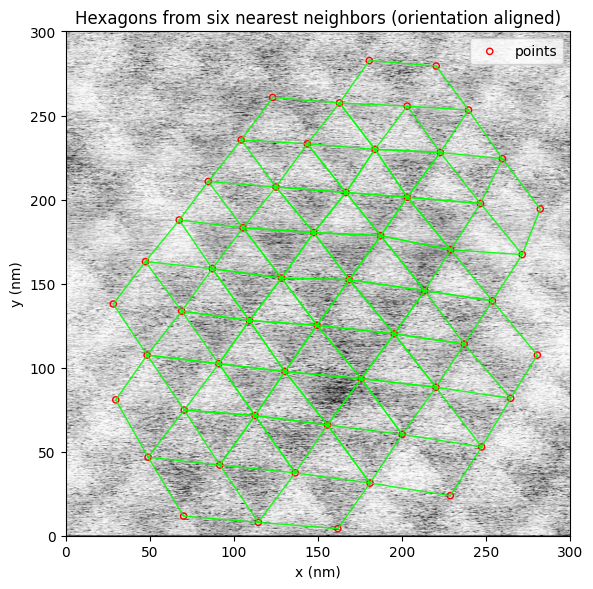

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree

# ---------- inputs you already set ----------
# df: DataFrame of image data (NY x NX), FIELD_NM, NX, NY defined earlier
# x_nm, y_nm: arrays of picked coordinates (same units as FIELD_NM)

# --------------------------------------------------
# 0) Make image orientation explicit & consistent
# --------------------------------------------------
# Choose ONE mode:
ALIGN_MODE = "flip_image"   # or "flip_coords"

# Build an "extent" for imshow that maps array indices to 0..FIELD_NM for both axes
extent = [0, FIELD_NM, 0, FIELD_NM]

if ALIGN_MODE == "flip_image":
    # Flip the image vertically so row 0 maps to y=FIELD_NM (top), not y=0.
    # After flipping, origin="lower" with extent works with your raw (x_nm, y_nm).
    img_plot = np.flipud(df.values)
    x_plot = x_nm.copy()
    y_plot = y_nm.copy()
    origin = "lower"

elif ALIGN_MODE == "flip_coords":
    # Keep the image as-is and transform coordinates to match the array’s y-direction.
    # If df row 0 is the TOP of the image, flipping coordinates aligns overlays.
    img_plot = df.values
    x_plot = x_nm.copy()
    y_plot = FIELD_NM - y_nm  # flip y coordinates only
    origin = "lower"          # if your image was written top->bottom, use "upper" instead

else:
    raise ValueError("ALIGN_MODE must be 'flip_image' or 'flip_coords'")

# --------------------------------------------------
# 1) Build hexagons by connecting the six nearest neighbors
# --------------------------------------------------
points = np.column_stack([x_plot, y_plot])       # (N, 2) in plot coordinates
tree = cKDTree(points)

# A typical nearest-neighbor spacing for gating
# (median distance to the 1st neighbor gives a good local scale)
d1, i1 = tree.query(points, k=2)   # k=2 returns [self, nearest]
median_nn = np.median(d1[:, 1])
max_factor = 1.55                   # allow up to 1.5× typical spacing
max_radius = max_factor * median_nn

hex_polys = []     # list of (M,2) polygons (we expect M=6, but we’ll be robust)
hex_indices = []   # indices of the center point used

for idx, center in enumerate(points):
    # get more than 6 to allow filtering; k=8 returns [self + 7 neighbors]
    dists, nbr_ids = tree.query(center, k=8)
    # Drop self
    mask = nbr_ids != idx
    dists = dists[mask]
    nbr_ids = nbr_ids[mask]

    # Distance sanity filter: keep neighbors inside a reasonable ring
    keep = dists <= max_radius
    nbr_ids = nbr_ids[keep]
    dists = dists[keep]

    if nbr_ids.size < 6:
        # Not enough close neighbors – skip (likely boundary or sparse area)
        continue

    # Keep the 6 closest
    order = np.argsort(dists)[:6]
    nbr_ids = nbr_ids[order]

    # Sort those 6 by angle around the center → a simple, consistent hexagon
    vecs = points[nbr_ids] - center
    angles = np.arctan2(vecs[:, 1], vecs[:, 0])   # (-pi, pi]
    sort_idx = np.argsort(angles)
    ring_ids = nbr_ids[sort_idx]
    ring_xy  = points[ring_ids]

    # Optionally enforce CCW orientation (positive signed area)
    x = ring_xy[:, 0]; y = ring_xy[:, 1]
    area2 = np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))
    if area2 < 0:
        ring_xy = ring_xy[::-1]

    hex_polys.append(ring_xy)
    hex_indices.append(idx)

print(f"Built {len(hex_polys)} hexagons from 6-neighbor rings.")

# --------------------------------------------------
# 2) Plot to verify alignment & hexagons
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_plot, cmap="gray", extent=extent, origin=origin)

# overlay points
ax.scatter(x_plot, y_plot, s=20, facecolors="none", edgecolors="red", linewidths=1.0, label="points")

# overlay hexagons
for poly in hex_polys:
    ax.plot(np.r_[poly[:,0], poly[0,0]], np.r_[poly[:,1], poly[0,1]],
            color="lime", linewidth=1.0, alpha=0.9)

ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("Hexagons from six nearest neighbors (orientation aligned)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


C:\Users\Elaina\AppData\Local\Temp\ipykernel_16444\405400501.py:169: RuntimeWarning: Mean of empty slice
  mean_hex = np.nanmean(stack, axis=0)


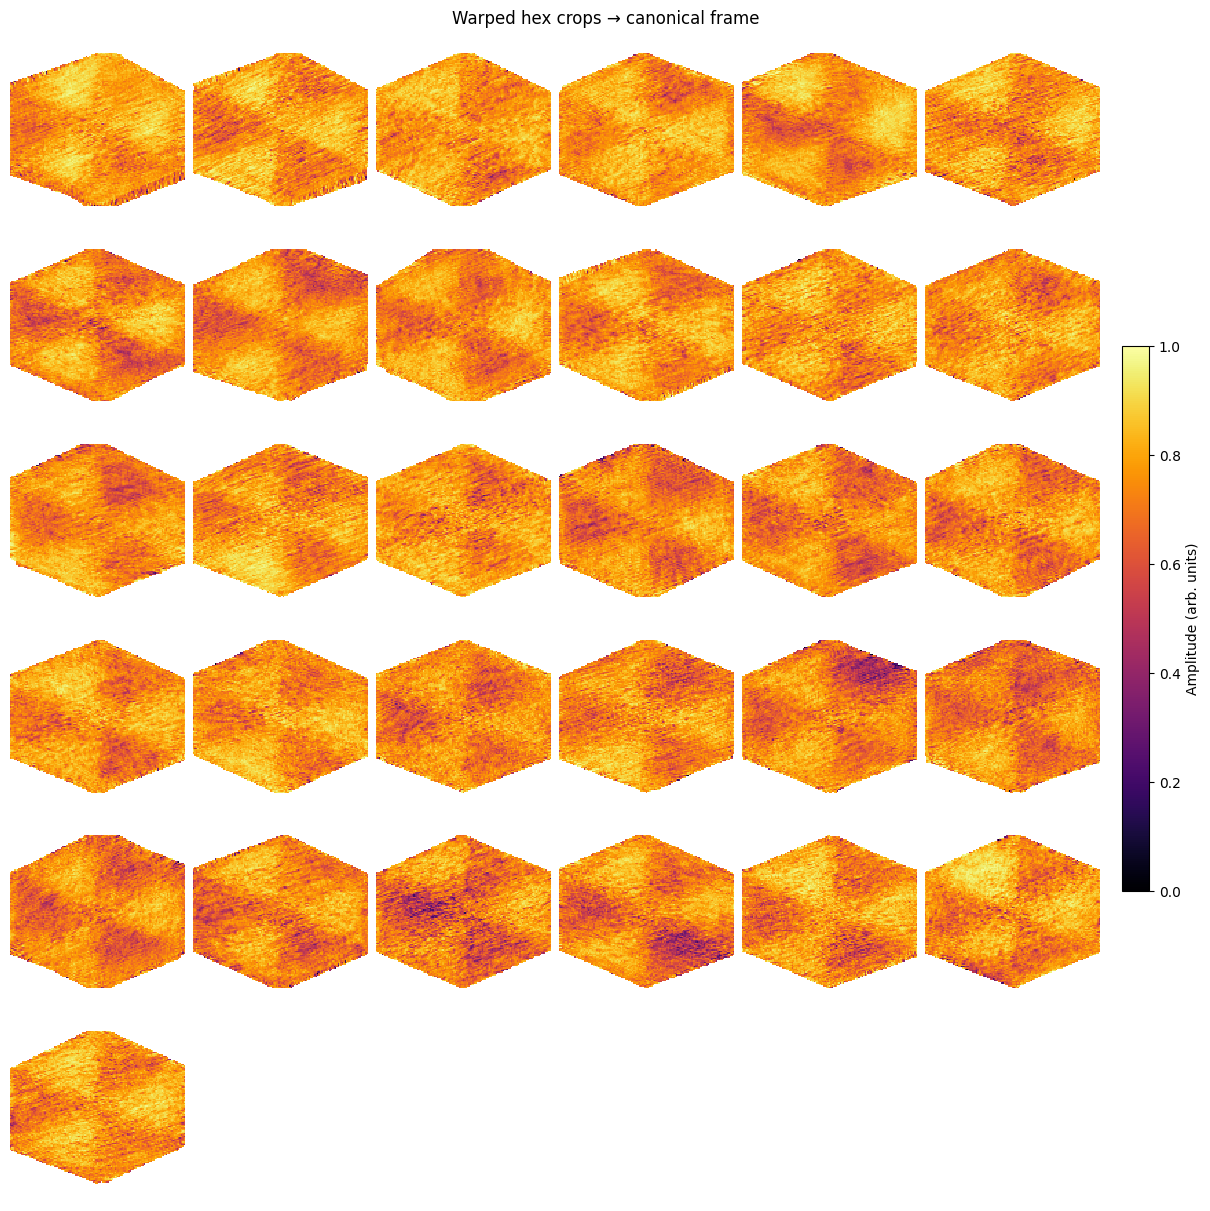

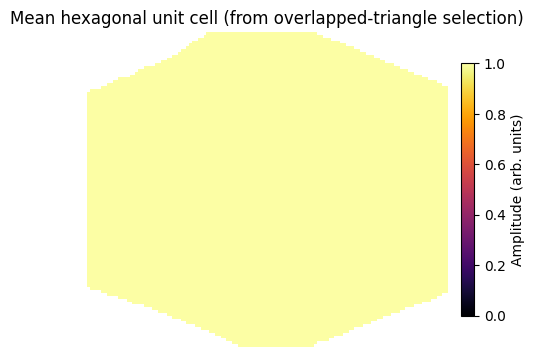

In [192]:
import numpy as np
import pandas as pd
from skimage.draw import polygon
from skimage.transform import AffineTransform, warp
import matplotlib.pyplot as plt

# ---------- 1) crop each hex from the plotted image ----------
def nm_to_pixel_xy(x_nm, y_nm, FIELD_NM, NX, NY, origin="lower"):
    col = (x_nm / FIELD_NM) * (NX - 1)
    if origin == "lower":
        row = (y_nm / FIELD_NM) * (NY - 1)
    else:  # 'upper'
        row = (1.0 - y_nm / FIELD_NM) * (NY - 1)
    return col, row

def crop_hex(img_plot, poly_nm, FIELD_NM, NX, NY, origin="lower", expand=1.00, pad_px=0):
    P = np.asarray(poly_nm, float)
    if expand != 1.0:
        C = P.mean(axis=0)
        P = C + expand*(P - C)

    cols_f, rows_f = nm_to_pixel_xy(P[:,0], P[:,1], FIELD_NM, NX, NY, origin=origin)

    cmin = int(np.floor(cols_f.min())) - pad_px
    cmax = int(np.ceil (cols_f.max())) + pad_px
    rmin = int(np.floor(rows_f.min())) - pad_px
    rmax = int(np.ceil (rows_f.max())) + pad_px
    cmin = max(0, cmin); rmin = max(0, rmin)
    cmax = min(NX-1, cmax); rmax = min(NY-1, rmax)
    if cmax < cmin or rmax < rmin:
        return None, None, None

    crop = img_plot[rmin:rmax+1, cmin:cmax+1].copy()

    rr, cc = polygon(rows_f - rmin, cols_f - cmin, shape=crop.shape)
    mask = np.zeros_like(crop, bool); mask[rr, cc] = True
    crop[~mask] = np.nan

    # axes in nm for this crop
    x0 = (cmin/(NX-1))*FIELD_NM; x1 = (cmax/(NX-1))*FIELD_NM
    if origin == "lower":
        y0 = (rmin/(NY-1))*FIELD_NM; y1 = (rmax/(NY-1))*FIELD_NM
    else:
        y0 = (1.0 - rmin/(NY-1))*FIELD_NM; y1 = (1.0 - rmax/(NY-1))*FIELD_NM

    x_nm_axis = np.linspace(x0, x1, cmax - cmin + 1)
    y_nm_axis = np.linspace(y0, y1, rmax - rmin + 1)
    return crop, y_nm_axis, x_nm_axis

def crop_all_hexes(img_plot, hex_polys, FIELD_NM, NX, NY, origin="lower", expand=1.00, pad_px=0):
    crops_np, crops_df = [], []
    for poly in hex_polys:
        crop, y_nm, x_nm = crop_hex(img_plot, poly, FIELD_NM, NX, NY, origin, expand, pad_px)
        if crop is None: 
            continue
        crops_np.append(crop)
        crops_df.append(pd.DataFrame(crop, index=np.round(y_nm,3), columns=np.round(x_nm,3)))
    return crops_np, crops_df

# ---------- 2) canonical hex geometry & orientation fix ----------
def triangle_dims_from_grid(GRID: int):
    return int(round((np.sqrt(3)/2)*(GRID-1))) + 1

def canonical_hex_frame(GRID: int):
    Ht = triangle_dims_from_grid(GRID)
    a  = GRID - 1
    h  = Ht - 1
    W_hex = 2*a + 1
    H_hex = 2*h + 1
    cx = (W_hex - 1)/2.0; cy = (H_hex - 1)/2.0
    V = np.array([
        [cx,     cy - h],       # top
        [cx + a, cy - h/2.0],   # upper-right
        [cx + a, cy + h/2.0],   # lower-right
        [cx,     cy + h],       # bottom
        [cx - a, cy + h/2.0],   # lower-left
        [cx - a, cy - h/2.0],   # upper-left
    ], float)
    C = np.array([cx, cy], float)
    return H_hex, W_hex, V, C

def canonicalize_hex_vertices(poly_nm, origin="lower"):
    P = np.asarray(poly_nm, float)
    # make CCW
    area2 = np.sum(P[:,0]*np.roll(P[:,1],-1) - P[:,1]*np.roll(P[:,0],-1))
    if area2 < 0:
        P = P[::-1]
    # start at 'top' vertex in plot coords
    start = np.argmax(P[:,1]) if origin=="lower" else np.argmin(P[:,1])
    P = np.roll(P, -start, axis=0)
    # ensure next is the upper-right (avoid mirror)
    if P[1,0] < P[0,0]:
        P = P[[0,5,4,3,2,1], :]
    return P

# map nm coords to local crop pixels
def nm_to_local_px(x_nm, y_nm, x_axis_nm, y_axis_nm, origin="lower"):
    x0,x1 = x_axis_nm[0], x_axis_nm[-1]
    y0,y1 = y_axis_nm[0], y_axis_nm[-1]
    Wc = len(x_axis_nm); Hc = len(y_axis_nm)
    col = (x_nm - x0) / (x1 - x0) * (Wc - 1)
    if origin=="lower":
        row = (y_nm - y0) / (y1 - y0) * (Hc - 1)
    else:
        row = (y0 - y_nm) / (y0 - y1) * (Hc - 1)
    return np.column_stack([col, row])

# ---------- 3) warp one hex crop → canonical hex ----------
def warp_hex_crop_to_canonical(crop_df, poly_nm, GRID=64, origin="lower"):
    crop = crop_df.values
    x_axis_nm = crop_df.columns.values
    y_axis_nm = crop_df.index.values

    H_hex, W_hex, V_canon, C_canon = canonical_hex_frame(GRID)
    poly_nm = canonicalize_hex_vertices(poly_nm, origin=origin)
    C_src_nm = poly_nm.mean(axis=0)

    acc = np.zeros((H_hex, W_hex), float)
    wgt = np.zeros((H_hex, W_hex), float)

    def base_left_right(p, q):
        return (p, q) if p[0] <= q[0] else (q, p)

    mask_src = np.isfinite(crop).astype(float)
    vals_src = np.where(np.isfinite(crop), crop, 0.0).astype(float)

    for k in range(6):
        p = V_canon[k]; q = V_canon[(k+1)%6]
        bl, br = base_left_right(p, q)
        dest = np.vstack([bl, br, C_canon])

        Ps = poly_nm[k]; Qs = poly_nm[(k+1)%6]
        src_nm = np.vstack([Ps, Qs, C_src_nm])
        src_px = nm_to_local_px(src_nm[:,0], src_nm[:,1], x_axis_nm, y_axis_nm, origin=origin)

        tf = AffineTransform()
        if not tf.estimate(src_px, dest):
            continue

        vals_w = warp(vals_src, inverse_map=tf.inverse,
                      output_shape=(H_hex, W_hex), order=1,
                      mode="constant", cval=0.0, preserve_range=True)
        w_w    = warp(mask_src, inverse_map=tf.inverse,
                      output_shape=(H_hex, W_hex), order=1,
                      mode="constant", cval=0.0, preserve_range=True)
        acc += vals_w
        wgt += w_w

    with np.errstate(invalid='ignore', divide='ignore'):
        canon = acc / wgt
    canon[wgt==0] = np.nan
    return canon

# ---------- 4) batch: crop → warp → average ----------
GRID = 64  # same base width you used for triangles; adjust as you like
crops_np, crops_df = crop_all_hexes(img_plot, hex_polys, FIELD_NM, NX, NY, origin=origin, expand=1.00, pad_px=0)

warped_hexes = []
for poly, df_crop in zip(hex_polys, crops_df):
    canon = warp_hex_crop_to_canonical(df_crop, poly, GRID=GRID, origin=origin)
    if canon.size:
        warped_hexes.append(canon)

if not warped_hexes:
    raise RuntimeError("No warped hexes produced. Check alignment or inputs.")

stack = np.stack(warped_hexes, axis=0)
with np.errstate(invalid='ignore'):
    mean_hex = np.nanmean(stack, axis=0)

# ---------- 5) quick galleries ----------
def gallery(images, title="", ncols=6, cmap="inferno", share=True):
    if not images: 
        print("No images."); 
        return
    n = len(images); ncols = min(ncols, n); nrows = (n + ncols - 1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.0*ncols, 2.0*nrows), constrained_layout=True)
    axes = np.atleast_2d(axes).ravel()
    if share:
        vmin = np.nanmin([np.nanmin(im) for im in images])
        vmax = np.nanmax([np.nanmax(im) for im in images])
    else:
        vmin = vmax = None
    for ax, im in zip(axes, images):
        ax.imshow(np.ma.masked_invalid(im), origin="lower", cmap=cmap, interpolation="nearest",
                  vmin=vmin, vmax=vmax)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=axes.reshape(-1,1), fraction=0.025, pad=0.02)
    cbar.set_label("Amplitude (arb. units)")
    if title: plt.suptitle(title)
    plt.show()

gallery(warped_hexes, title="Warped hex crops → canonical frame", ncols=6, cmap="inferno", share=True)

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.0), constrained_layout=True)
im = ax.imshow(np.ma.masked_invalid(mean_hex), origin="lower",
               cmap="inferno", interpolation="nearest", vmin=0, vmax=1)
ax.set_title("Mean hexagonal unit cell (from overlapped-triangle selection)")
ax.axis("off")

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Amplitude (arb. units)")

# Adjust the height by modifying the colorbar axis position
cbar.ax.set_position([0.15, 0.1, 0.03, 0.1])  
# [left, bottom, width, height] in figure fraction coordinates

plt.show()


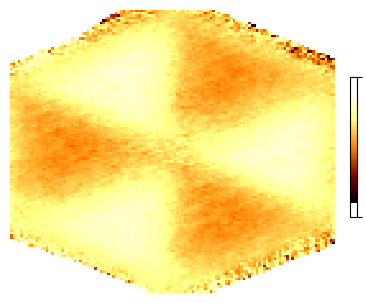

In [193]:
from matplotlib.ticker import NullFormatter  # <-- add this near your other imports

masked = np.ma.masked_invalid(mean_hex)
normed =  (masked - masked.min()) / (masked.max() - masked.min())


fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.0))
im = ax.imshow(normed, origin="lower", cmap="afmhot", interpolation="nearest", vmin=0.1, vmax=0.9)

ax.set_title("")
ax.axis("off")

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("", fontsize=10)
cbar.ax.yaxis.set_major_formatter(NullFormatter())
cbar.ax.yaxis.set_minor_formatter(NullFormatter())


cbar.ax.tick_params(labelsize=12)
cbar.set_ticks([0,1])
# Adjust the height by modifying the colorbar axis position
cbar.ax.set_position([0.88, 0.33, 1.5, 0.35])
# [left, bottom, width, height] in figure fraction coordinates

plt.show()


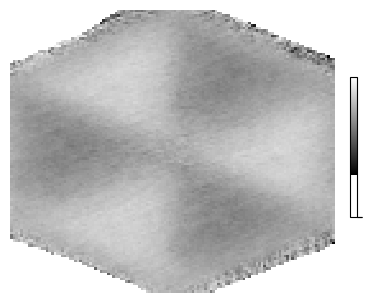

In [194]:
from matplotlib.ticker import NullFormatter  # <-- add this near your other imports

masked = np.ma.masked_invalid(mean_hex)

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.0))
im = ax.imshow(masked, origin="lower", cmap="gray", interpolation="nearest")

ax.set_title("")
ax.axis("off")

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("", fontsize=10)
cbar.ax.yaxis.set_major_formatter(NullFormatter())
cbar.ax.yaxis.set_minor_formatter(NullFormatter())


cbar.ax.tick_params(labelsize=12)
cbar.set_ticks([0,1])
# Adjust the height by modifying the colorbar axis position
cbar.ax.set_position([0.88, 0.33, 1.5, 0.35])
# [left, bottom, width, height] in figure fraction coordinates

plt.show()

In [195]:
masked = np.ma.masked_invalid(mean_hex)
print("Min:", masked.min())
print("Max:", masked.max())

Min: 74.07179979245781
Max: 244.0


a1 = [-0.49469652  0.77014281]
a2 = [-1.13180885 -0.07167353]


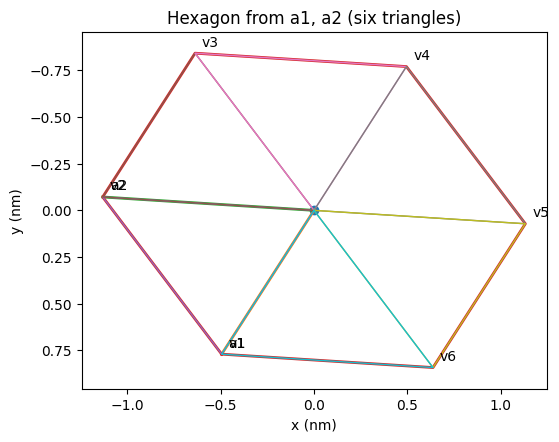

In [210]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Conventions ----------
# Matches your Julia code:
#   arot(theta) = [[cosθ, sinθ], [-sinθ, cosθ]]  (CW-positive)
#   S = R^T * diag(-ε, ν ε) * R,   R = arot(φ)
#   T = S + [[0, -θ], [θ, 0]]
#   M = arot(α) * inv(T)
#   a1 = M * A1, a2 = M * A2

def arot(theta: float) -> np.ndarray:
    """Clockwise-positive rotation (same as Julia arot)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c,  s],
                     [-s, c]], dtype=float)

def strained_lattice(alpha: float,
                     eps_percent: float,
                     phi: float,
                     theta: float,
                     a: float = 0.01,
                     nu: float = 0.01) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (a1, a2) using the same conventions as your Julia 'strainedlattice'.

    Parameters (radians, percent):
      alpha        - global rotation (CW-positive)
      eps_percent  - ε in percent (e.g., 0.288 means 0.288%)
      phi          - principal-strain axis angle (CW from +x)
      theta        - small rigid rotation term (radians)
      a            - lattice constant in nm
      nu           - Poisson ratio
    """
    A1 = np.array([a/2.0, -a*np.sqrt(3)/2.0], dtype=float)
    A2 = np.array([a, 0.0], dtype=float)

    R   = arot(phi)
    eps = 0.01 * eps_percent
    S   = R.T @ np.array([[-eps, 0.0],
                          [ 0.0, nu*eps]], float) @ R
    Omega = np.array([[0.0, -theta],
                      [theta,  0.0]], float)
    T = S + Omega

    M = arot(alpha) @ np.linalg.inv(T)

    a1 = M @ A1
    a2 = M @ A2
    return a1, a2

# ---------- Hexagon construction from a1, a2 ----------
def hex_vertices_from_a1a2(a1: np.ndarray, a2: np.ndarray) -> np.ndarray:
    """
    Construct the 6 hexagon corners from center using the two corner radii a1, a2.
    Order is CCW (will flip if needed).
    """
    a1 = np.asarray(a1, float)
    a2 = np.asarray(a2, float)
    v1 = a1
    v2 = a2
    v3 = a2 - a1
    v4 = -a1
    v5 = -a2
    v6 = -v3
    verts = np.stack([v1, v2, v3, v4, v5, v6], axis=0)

    # Ensure CCW order by signed area
    area = 0.5 * np.sum(verts[:, 0] * np.roll(verts[:, 1], -1)
                        - verts[:, 1] * np.roll(verts[:, 0], -1))
    if area < 0:
        verts = verts[::-1]
    return verts

def hex_triangles_from_center(verts: np.ndarray) -> list[np.ndarray]:
    """
    Given the 6 CCW vertices (center-based), return the 6 triangles
    [ [0,0] → vi → v(i+1) → [0,0] ] as arrays of shape (3,2).
    """
    tris = []
    for i in range(6):
        vi  = verts[i]
        vj  = verts[(i+1) % 6]
        tris.append(np.vstack([[0.0, 0.0], vi, vj]))
    return tris

# ---------- Plotting ----------
def plot_hex_and_triangles(a1: np.ndarray, a2: np.ndarray,
                           show_triangles: bool = True,
                           annotate: bool = True) -> None:
    """Plot a1, a2, the hexagon, and optionally the 6 constituent triangles."""
    verts = hex_vertices_from_a1a2(a1, a2)

    fig, ax = plt.subplots(figsize=(6, 6))

    # center
    ax.plot(0, 0, marker='o')

    # the two radii
    ax.plot([0, a1[0]], [0, a1[1]], linewidth=2)
    ax.plot([0, a2[0]], [0, a2[1]], linewidth=2)

    # hexagon boundary
    poly = np.vstack([verts, verts[0]])
    ax.plot(poly[:, 0], poly[:, 1], linewidth=2)

    # triangles
    if show_triangles:
        for tri in hex_triangles_from_center(verts):
            p = np.vstack([tri, [0.0, 0.0]])  # close
            ax.plot(p[:, 0], p[:, 1], linewidth=1)

    # annotations
    if annotate:
        for i, (x, y) in enumerate(verts, start=1):
            ax.annotate(f"v{i}", (x, y), textcoords="offset points", xytext=(5, 5))
        ax.annotate("a1", (a1[0], a1[1]), textcoords="offset points", xytext=(5, 5))
        ax.annotate("a2", (a2[0], a2[1]), textcoords="offset points", xytext=(5, 5))

    all_pts = np.vstack([[[0, 0]], verts])
    pad = 0.1 * np.max(np.linalg.norm(verts, axis=1))
    xmin, ymin = all_pts.min(axis=0) - pad
    xmax, ymax = all_pts.max(axis=0) + pad
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_title("Hexagon from a1, a2 (six triangles)")
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()          # <-- match PFM (y downward)
    plt.show()

# ---------- Example use ----------
if __name__ == "__main__":
    # Example params (radians and percent)
    alpha  = np.deg2rad(83.38)
    epspct = 0.2394       # 0.288%
    phi    = np.deg2rad(-29.6)
    theta  = np.deg2rad(0.56)

    a1, a2 = strained_lattice(alpha, epspct, phi, theta)
    print("a1 =", a1)
    print("a2 =", a2)

    plot_hex_and_triangles(a1, a2, show_triangles=True, annotate=True)


In [211]:
import numpy as np
from skimage.transform import AffineTransform, warp
from skimage.draw import polygon
import matplotlib.pyplot as plt

# ===== 1) Canonical hex frame derived from your mean-hex array =====
def canonical_hex_from_array(arr):
    """
    Rebuild the canonical 6 vertices (pixel coords) and centroid that match the
    frame used to generate the averaged hex array (arr).
    """
    Hc, Wc = arr.shape
    a  = (Wc - 1) / 2.0
    h  = (Hc - 1) / 2.0
    cx = (Wc - 1) / 2.0
    cy = (Hc - 1) / 2.0
    Vc = np.array([
        [cx,     cy - h],        # top
        [cx + a, cy - h/2.0],    # upper-right
        [cx + a, cy + h/2.0],    # lower-right
        [cx,     cy + h],        # bottom
        [cx - a, cy + h/2.0],    # lower-left
        [cx - a, cy - h/2.0],    # upper-left
    ], float)
    Cc = np.array([cx, cy], float)
    return Vc, Cc

def _edge_len_avg(V):
    return float(np.mean([np.linalg.norm(V[(i+1)%6] - V[i]) for i in range(6)]))

def _ensure_ccw_topstart(V):
    """Ensure CCW, start at highest-y (top), next vertex to the right."""
    V = np.asarray(V, float)
    area2 = np.sum(V[:,0]*np.roll(V[:,1],-1) - V[:,1]*np.roll(V[:,0],-1))
    if area2 < 0:  # make CCW
        V = V[::-1]
    start = np.argmax(V[:,1])      # topmost
    V = np.roll(V, -start, axis=0)
    if V[1,0] < V[0,0]:            # fix mirror
        V = V[[0,5,4,3,2,1], :]
    return V

# ===== 2) Warp canonical → target hex (piecewise-affine per wedge) =====
def warp_canonical_to_target_hex(mean_hex,
                                 V_target_xy,
                                 px_per_unit=None,
                                 pad_units=0.0,
                                 order=0,                 # 0=nearest (crisp), 1=bilinear, 3=bicubic
                                 blend="overwrite"):      # "overwrite" (crisp seams) or "average"
    """
    mean_hex: (H,W) canonical averaged hex, masked by NaN outside
    V_target_xy: (6,2) target hex vertices (same units as your a1/a2)
    Returns: img_out, y_axis, x_axis (axes in target units)
    """
    Vc, Cc = canonical_hex_from_array(mean_hex)
    edge_canon_px   = np.linalg.norm(Vc[1] - Vc[0])
    Vt = _ensure_ccw_topstart(V_target_xy)
    Ct = Vt.mean(axis=0)
    edge_target_u   = _edge_len_avg(Vt)

    # sampling density: match canonical edge pixel density by default
    if px_per_unit is None:
        px_per_unit = edge_canon_px / edge_target_u

    xmin, ymin = Vt.min(axis=0) - pad_units
    xmax, ymax = Vt.max(axis=0) + pad_units

    def to_out_px(XY):
        X = (XY[:,0] - xmin) * px_per_unit
        Y = (XY[:,1] - ymin) * px_per_unit
        return np.column_stack([X, Y])

    Vt_px = to_out_px(Vt)
    Ct_px = to_out_px(Ct[None,:])[0]
    Wout  = int(np.ceil((xmax - xmin) * px_per_unit)) + 1
    Hout  = int(np.ceil((ymax - ymin) * px_per_unit)) + 1

    vals_src = np.where(np.isfinite(mean_hex), mean_hex, 0.0).astype(float)
    mask_src = np.isfinite(mean_hex).astype(float)
    acc = np.zeros((Hout, Wout), float)
    wgt = np.zeros((Hout, Wout), float)

    for k in range(6):
        src_tri = np.vstack([Vc[k], Vc[(k+1)%6], Cc])
        dst_tri = np.vstack([Vt_px[k], Vt_px[(k+1)%6], Ct_px])

        tf = AffineTransform()
        if not tf.estimate(src=src_tri, dst=dst_tri):
            continue

        vals_w = warp(vals_src, inverse_map=tf.inverse,
                      output_shape=(Hout, Wout), order=order,
                      mode="constant", cval=0.0, preserve_range=True)
        w_w    = warp(mask_src, inverse_map=tf.inverse,
                      output_shape=(Hout, Wout), order=order,
                      mode="constant", cval=0.0, preserve_range=True)

        if blend == "overwrite":
            write_mask = (wgt == 0) & (w_w > 0)
            acc[write_mask] = vals_w[write_mask]
            wgt[write_mask] = 1.0
        else:  # average
            acc += vals_w
            wgt += w_w

    with np.errstate(invalid='ignore', divide='ignore'):
        out = acc / wgt
    out[wgt == 0] = np.nan

    # crisp polygon mask
    rr, cc = polygon(Vt_px[:,1], Vt_px[:,0], shape=out.shape)
    mask = np.zeros_like(out, bool); mask[rr, cc] = True
    out[~mask] = np.nan

    x_axis = np.linspace(xmin, xmax, Wout)
    y_axis = np.linspace(ymin, ymax, Hout)
    return out, y_axis, x_axis

# ===== 3) Glue: take your a1,a2 → target hex → warp `normed` → plot (fixed 0..1 range) =====
def warp_and_plot_to_a1a2_target(normed, a1, a2,
                                 px_per_unit=None,
                                 order=0, blend="overwrite",
                                 outline=True, clean=True):
    # Build the target hex from your a1,a2
    V_target = hex_vertices_from_a1a2(a1, a2)
    img_out, y_ax, x_ax = warp_canonical_to_target_hex(
        mean_hex=normed,
        V_target_xy=V_target,
        px_per_unit=px_per_unit,
        pad_units=0.0,
        order=order,
        blend=blend
    )

    fig, ax = plt.subplots(figsize=(5.2, 5.0), constrained_layout=True)
    ax.imshow(np.ma.masked_invalid(img_out),
              origin="lower",
              extent=[x_ax[0], x_ax[-1], y_ax[0], y_ax[-1]],
              cmap="afmhot",
              interpolation="nearest",
              vmin=0.0, vmax=1.0)  # lock contrast to your normed scale
    if outline:
        Vp = np.vstack([V_target, V_target[0]])
        ax.plot(Vp[:,0], Vp[:,1], '-', lw=1.2, color='white', alpha=0.9)
    ax.set_aspect('equal', adjustable='box')

    if clean:
        # hide axes/labels/spines
        ax.set_title(""); ax.set_xlabel(""); ax.set_ylabel("")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        ax.set_axis_off()
        
        
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()          # <-- match PFM (y downward)

    plt.show()
    return img_out, y_ax, x_ax


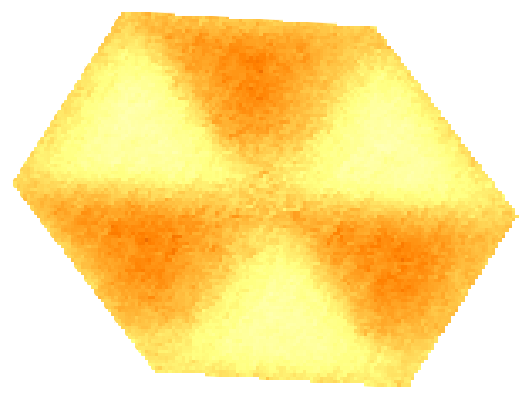

In [212]:
img_out, y_ax, x_ax = warp_and_plot_to_a1a2_target(
    normed=normed,
    a1=a1,
    a2=a2,
    px_per_unit=None,   # auto: matches canonical pixel density along edges
    order=0,            # nearest for no blur; try 1 or 3 if you want smoother interiors
    blend="overwrite",  # crisper seams; use "average" for seam smoothing
    outline=True,
    clean=True
)